## 1. Get basic info - shape, column names, datatypes, statistical summary

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# load dataset
df = pd.read_csv("iris.csv")

# show first rows
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [63]:
print("Shape of dataset:", df.shape)

Shape of dataset: (150, 6)


In [64]:
print("Column names:")
print(df.columns)

Column names:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


In [65]:
print("Data types:")
print(df.dtypes)

Data types:
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object


In [66]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


### 1. Interpretation
- Dataset contains 150 samples
- No obvious issues in data types
- Features appear numeric except species

## 2. Check missing values, duplicates

In [67]:
# check missing values
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [68]:
# show only duplicate rows
#df[df.duplicated()]
print("Duplicates: ", df.duplicated().sum())

Duplicates:  0


### 2. Interpretation
- No missing values found in the dataset
- Dataset contains no duplicates

## 3. Check dataset balance

In [69]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

### 3. Interpretation
The dataset is perfectly balanced.
Each species has an equal number of samples (50).

## 4. Feature Distributions (Histograms)
Histogram for features - univariate analysis

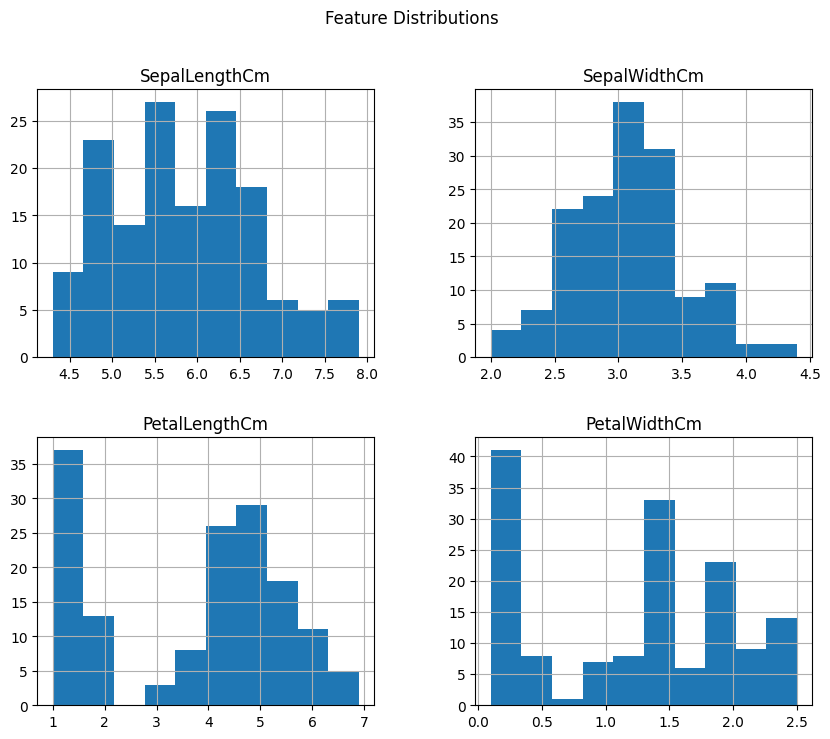

In [70]:
df = df.drop(columns=['Id'])
df.hist(figsize=(10,8))
plt.suptitle("Feature Distributions")
plt.show()

### 4. Interpretation
- Most features show a roughly normal distribution
- Petal length and petal width show clear separation between classes

## 5. Skewness
Detect skewness

In [71]:
df.skew(numeric_only=True)

SepalLengthCm    0.314911
SepalWidthCm     0.334053
PetalLengthCm   -0.274464
PetalWidthCm    -0.104997
dtype: float64

### 5. Interpretation
- Values close to 0 indicate normal distribution
- Positive skew means tail on the right side
- Negative skew means tail on the left side
- Most features in Iris dataset are fairly symmetrical

## 6. Boxplots (Feature vs Species)
Boxplot - bivariate analysis between features and species

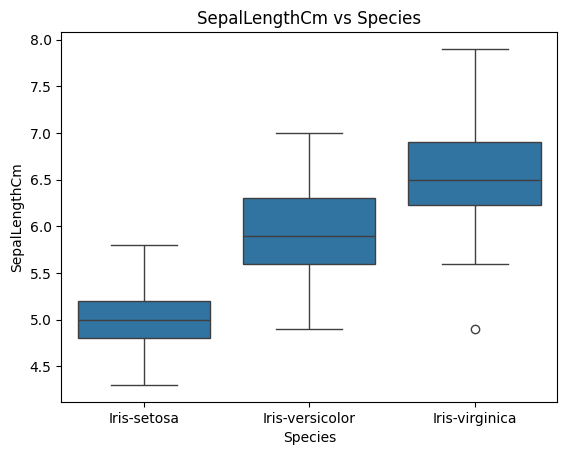

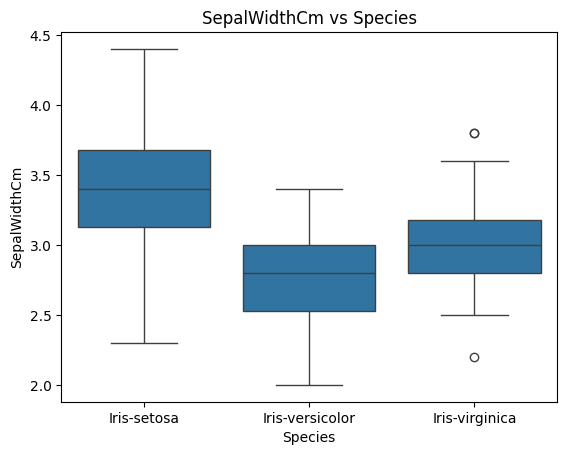

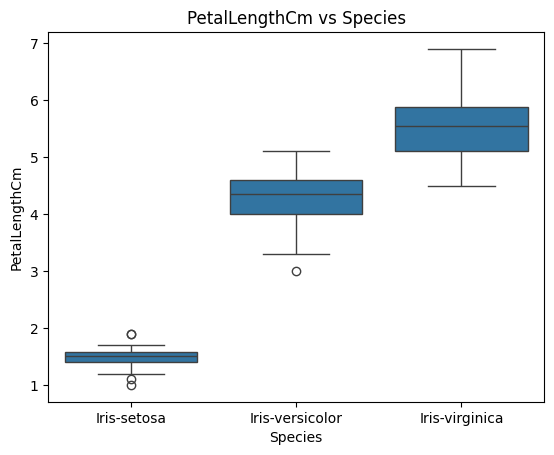

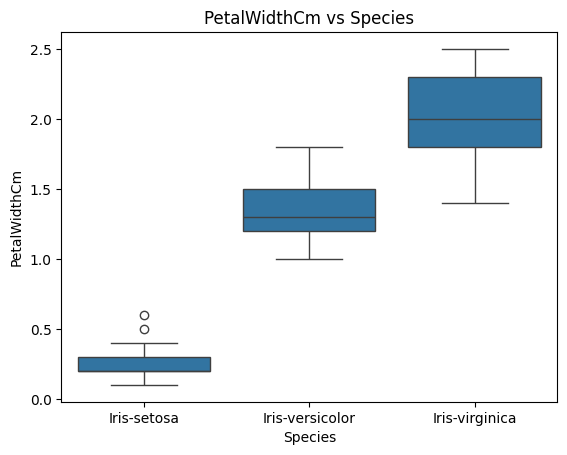

In [72]:
for col in df.columns[:-1]:
    sns.boxplot(x='Species', y=col, data=df)
    plt.title(f"{col} vs Species")
    plt.show()

### 6. Interpretation

The boxplots show how each feature varies across different species.

- Petal length and petal width clearly separate the species, especially Setosa from the others.
- Setosa has significantly smaller petal measurements compared to Versicolor and Virginica.
- Sepal length and sepal width show more overlap between species, making them less useful for classification.
- There are few or no significant outliers in the dataset.
- Overall, petal features are more important and informative for distinguishing between species.

## 7. Scatter Plot
The relationship between two features and how they separate different species.

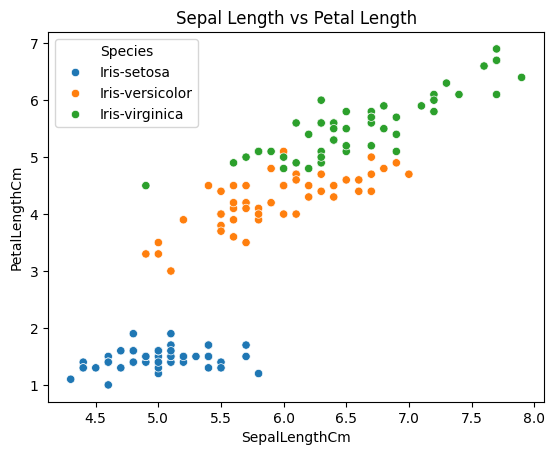

In [73]:
sns.scatterplot(x='SepalLengthCm', y='PetalLengthCm', hue='Species', data=df)
plt.title("Sepal Length vs Petal Length")
plt.show()

### 7. Interpretation

- Setosa is clearly separated from the other species.
- Versicolor and Virginica show some overlap but are still somewhat distinguishable.
- Petal length plays a key role in separating the species.

Conclusion:
There is a strong relationship between features, and petal length is especially useful for classification.

## 8. Outlier Detection
Potential outliers in the dataset using the IQR method.

In [74]:
import numpy as np

for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    
    print(f"\n{col} -> Outliers: {len(outliers)}")
    print(f"\n{col} outliers:", outliers)


SepalLengthCm -> Outliers: 0

SepalLengthCm outliers: Empty DataFrame
Columns: [SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm, Species]
Index: []

SepalWidthCm -> Outliers: 4

SepalWidthCm outliers:     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm          Species
15            5.7           4.4            1.5           0.4      Iris-setosa
32            5.2           4.1            1.5           0.1      Iris-setosa
33            5.5           4.2            1.4           0.2      Iris-setosa
60            5.0           2.0            3.5           1.0  Iris-versicolor

PetalLengthCm -> Outliers: 0

PetalLengthCm outliers: Empty DataFrame
Columns: [SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm, Species]
Index: []

PetalWidthCm -> Outliers: 0

PetalWidthCm outliers: Empty DataFrame
Columns: [SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm, Species]
Index: []


### 8. Interpretation

- The IQR method was used to detect outliers in numerical features.
- The Iris dataset generally contains very few or no significant outliers.
- The dataset is clean and suitable for further analysis.

## 10. Correlation Matrix & Heatmap
The relationships between numerical features using correlation and visualization.

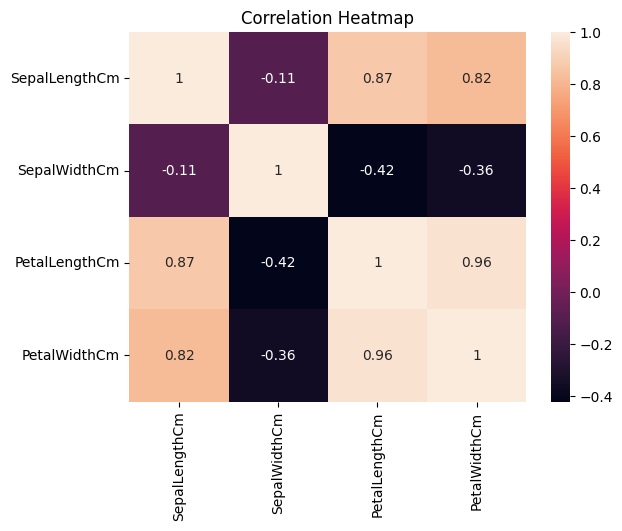

In [75]:
# correlation matrix
corr = df.corr(numeric_only=True)

# heatmap
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()